First visualization of some images from the dataset

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/_shared/utils.py:328: UserWarning: ./data/preprocessed/masks_100/ds8_pexels-photo-91626.png is a low contrast image
  return func(*args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/_shared/utils.py:328: UserWarning: ./data/preprocessed/masks_100/ds2_pexels-photo-413793.png is a low contrast image
  return func(*args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/_shared/utils.py:328: UserWarning: ./data/preprocessed/masks_100/ds6_pexels-photo-322458.png is a low contrast image
  return func(*args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skimage/_shared/utils.py:328: UserWarning: ./data/preprocessed/masks_100/ds2_man-stress-male-face.png is a low contrast image
  return func(*args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/p

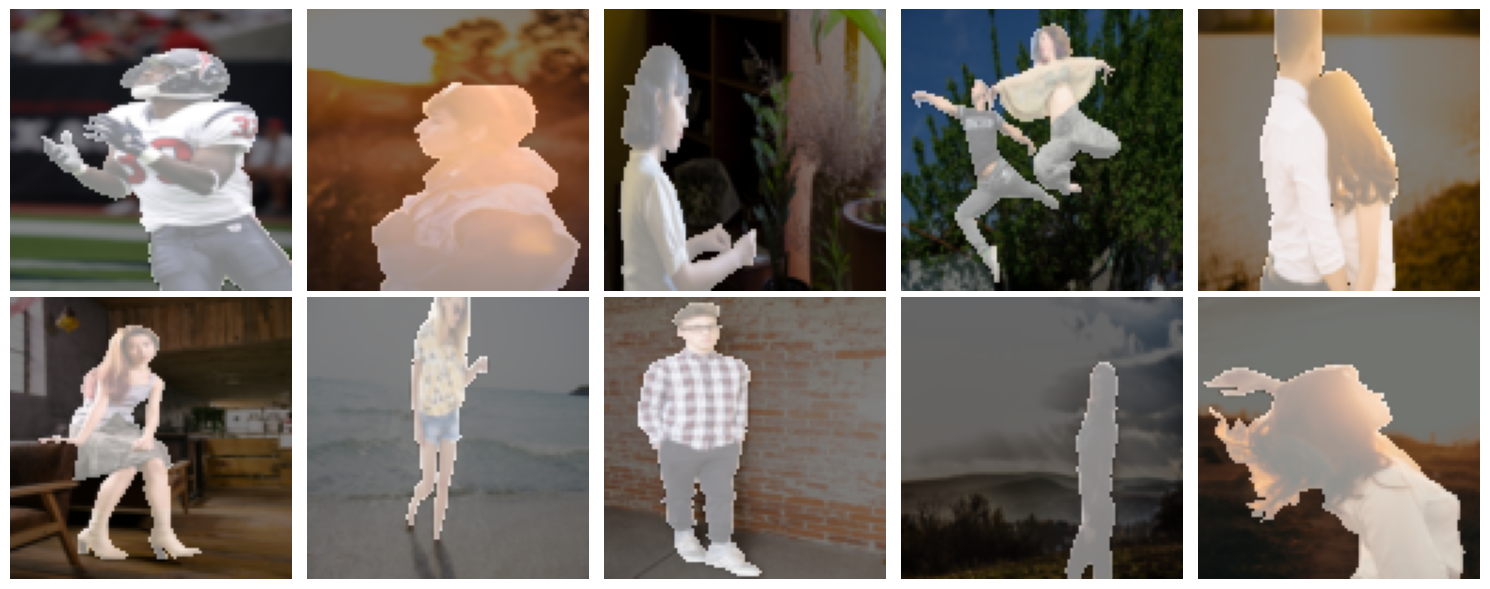

In [1]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np

from skimage import io
from skimage.transform import resize

# cartelle input
path_img_in   = "./data/supervisely_person_clean_2667_img/images"
path_mask_in  = "./data/supervisely_person_clean_2667_img/masks"

# cartelle output (100x100)
path_img_out  = "./data/preprocessed/images_100"
path_mask_out = "./data/preprocessed/masks_100"

os.makedirs(path_img_out, exist_ok=True)
os.makedirs(path_mask_out, exist_ok=True)

png_files = [f for f in os.listdir(path_img_in) if f.endswith(".png")]

def resize_and_center_crop_100(img, is_mask=False):
    h, w = img.shape[:2]

    # la dimensione minore diventa 100, l'altra scalata proporzionalmente
    if h < w:
        scale = 100.0 / h
    else:
        scale = 100.0 / w

    new_h = int(round(h * scale))
    new_w = int(round(w * scale))

    order = 0 if is_mask else 1
    anti_aliasing = False if is_mask else True

    img_resized = resize(
        img,
        (new_h, new_w),
        order=order,
        anti_aliasing=anti_aliasing,
        preserve_range=True
    )

    img_resized = img_resized.astype(img.dtype)

    # crop centrale 100x100
    start_y = (new_h - 100) // 2
    start_x = (new_w - 100) // 2
    img_cropped = img_resized[start_y:start_y + 100, start_x:start_x + 100]

    return img_cropped

# 1) PREPROCESSING: ridimensiona TUTTE le immagini e maschere
for name in png_files:
    img_path  = os.path.join(path_img_in, name)
    mask_path = os.path.join(path_mask_in, name)

    img  = io.imread(img_path)   # H x W x C
    mask = io.imread(mask_path)  # H x W (o H x W x C)

    if mask.ndim == 3:
        mask = mask[..., 0]

    img_proc  = resize_and_center_crop_100(img,  is_mask=False)
    mask_proc = resize_and_center_crop_100(mask, is_mask=True)

    # opzionale: binarizza la maschera
    if mask_proc.dtype != np.bool_:
        mask_proc = (mask_proc > 0.5).astype(np.uint8)

    io.imsave(os.path.join(path_img_out, name), img_proc)
    io.imsave(os.path.join(path_mask_out, name), mask_proc)

# 2) VISUALIZZA 10 IMMAGINI CASUALI PREPROCESSATE
all_pre = [f for f in os.listdir(path_img_out) if f.endswith(".png")]
random_images = random.sample(all_pre, min(10, len(all_pre)))  # 10 random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, img_name in enumerate(random_images):
    img_path  = os.path.join(path_img_out, img_name)
    mask_path = os.path.join(path_mask_out, img_name)

    img  = io.imread(img_path)
    mask = io.imread(mask_path)

    axes[idx].imshow(img)
    axes[idx].imshow(mask, alpha=0.5, cmap="gray")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


todo:
prendi due pixel uno bianco e uno nero di un immagine. crea un immagine quadrata con estremi quei due punti. 
creare le background e image patches.

Poi creeremo un classifier che data una patch, stabilisce a che classe appartiene

In [ ]:
import numpy as np
import os
from PIL import Image

def pick_random_centers(mask, size=100, ignore=0):
    #Ignoring borders
    mask_ignored = mask.copy()
    mask_ignored[:ignore, :] = False
    mask_ignored[-ignore:, :] = False
    mask_ignored[:, :ignore] = False
    mask_ignored[:, -ignore:] = False
    
    rs, cs = np.where(mask_ignored)
    
    if len(rs) == 0:
        return np.array([]), np.array([])
    
    ix = np.random.randint(len(rs), size=min(size, len(rs)))
    return rs[ix], cs[ix]

def extract_patches_from_image(img_array, mask_array, n_patches_per_class, radius):
    patches = []
    labels = []
    
    # Converti maschera in booleano
    mask_bool = mask_array > 127
    
    # Estrai patch TRUE (persona)
    rs, cs = pick_random_centers(mask_bool, size=n_patches_per_class, ignore=radius)
    for r, c in zip(rs, cs):
        patch = img_array[r-radius:r+radius, c-radius:c+radius, :]
        patches.append(patch.flatten())
        labels.append(1)
    
    # Estrai patch FALSE (background)
    rs, cs = pick_random_centers(~mask_bool, size=n_patches_per_class, ignore=radius)
    for r, c in zip(rs, cs):
        patch = img_array[r-radius:r+radius, c-radius:c+radius, :]
        patches.append(patch.flatten())
        labels.append(0)
    
    return patches, labels


def create_patch_dataset(image_files, path_img, path_mask, radius, n_patches_per_class):
    X = []
    y = []
    
    for img_name in image_files:
        img = Image.open(os.path.join(path_img, img_name))
        mask = Image.open(os.path.join(path_mask, img_name))
        
        img_array = np.array(img)
        mask_array = np.array(mask)
        
        # patch extraction
        patches, labels = extract_patches_from_image(img_array, mask_array, 
                                                     n_patches_per_class, radius)
        
        X.extend(patches)
        y.extend(labels)
    
    return np.array(X), np.array(y)



: 

In [ ]:
import keras
import keras.layers
import tensorflow as tf

def mkmodel():
    input_layer = keras.Input(shape=(None, None, 3), name='input')

    # --- ENCODER ---
    # First block
    x = keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')(input_layer)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.SeparableConv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')(x)# Efficient conv
    # Convoluzione Separabile: Divide il lavoro in due passaggi più semplici:
    # - Depthwise: Analizza solo lo spazio (forme, bordi) canale per canale.
    # - Pointwise (1x1): Mescola i canali (colori, feature) tra loro.

    x = keras.layers.BatchNormalization()(x)
    x1 = x # Save for skip connection
    
    # Downsample
    x = keras.layers.MaxPooling2D(2)(x) 
    # Lavora sull'immagine rimpicciolita. 
    # Cerca forme più complesse (occhi, mani). Usa 64 filtri (più "neuroni" per capire meglio).

    # Instead of 4-8... filters, we start with 32 and go up to 128. 
    # This provides more capacity to learn complex features

    # Second block
    x = keras.layers.SeparableConv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.SeparableConv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x2 = x # Save for skip connection
    
    # Downsample
    x = keras.layers.MaxPooling2D(2)(x) 

    # Bottleneck - the most abstract features. Qui l'immagine e' molto rimpicciolita
    x = keras.layers.SeparableConv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.SeparableConv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)

    # --- DECODER ---
    #
    # il modello torna alle dimensioni originali per dipingere la mask.

    # Upsample and Skip Connection 1
    x = keras.layers.UpSampling2D(2)(x)
    x = keras.layers.Concatenate()([x, x2]) # Il modello prende quello che ha capito (dal cervello) e lo unisce alle info dettagliate salvate prima 
    
    x = keras.layers.SeparableConv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.SeparableConv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')(x) 
    x = keras.layers.BatchNormalization()(x)

    # Upsample and Skip Connection 2
    x = keras.layers.UpSampling2D(2)(x)
    x = keras.layers.Concatenate()([x, x1])
    
    x = keras.layers.SeparableConv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.SeparableConv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)

    # Output layer
    x = keras.layers.Conv2D(filters=1, kernel_size=(1,1), padding='same', activation='sigmoid')(x)
    
    return keras.Model(input_layer, x)

# Creating the model
model = mkmodel()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Lower LR usually better for deeper nets
              loss=keras.losses.BinaryCrossentropy(from_logits=False), 
              metrics=[keras.metrics.BinaryAccuracy()])

model.summary()

Il modello ha una forma a "U": prima rimpicciolisce l'immagine per capirne il contenuto (Encoder), poi la ingrandisce per creare la maschera finale (Decoder).

ENCODER:
Questa parte serve a capire "COSA" c'è nell'immagine ("c'è una persona"), sacrificando il "DOVE" (i dettagli precisi).

In [ ]:
all_pre = [f for f in os.listdir(path_img_out) if f.endswith(".png")]
all_pre.sort()

X = []
Y = []

for name in all_pre:
    img_path  = os.path.join(path_img_out, name)
    mask_path = os.path.join(path_mask_out, name)

    img  = io.imread(img_path)
    mask = io.imread(mask_path)

    if mask.ndim == 2:
        mask = np.expand_dims(mask, axis=-1)

    #Normalizzazione delle immagini
    img  = img.astype("float32") / 255.0      
    mask = mask.astype("float32")             

    X.append(img)
    Y.append(mask)

X = np.stack(X, axis=0)
Y = np.stack(Y, axis=0)

N = X.shape[0]
indices = np.arange(N)
np.random.seed(42)
np.random.shuffle(indices)

split = int(0.8 * N)
train_idx = indices[:split]
test_idx  = indices[split:]

X_train, Y_train = X[train_idx], Y[train_idx]
X_test,  Y_test  = X[test_idx],  Y[test_idx]



import matplotlib.pyplot as plt
import tensorflow as tf

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="./logs")

ntest = 10
tx = X_test[:ntest]           # prime 10 immagini di test
ty = Y_test[:ntest]           # prime 10 maschere di test

while True:
    # Predizione sulle 10 immagini di test selezionate
    tyhat = model.predict(tx)

    fig, axs = plt.subplots(nrows=4, ncols=ntest, figsize=(2*ntest, 8))

    for ti in range(ntest):
        # immagine di input
        axs[0, ti].imshow(tx[ti])
        axs[0, ti].set_title(f"Img {ti}")
        # mappa di probabilità [0,1]
        axs[1, ti].imshow(tyhat[ti, :, :, 0], vmin=0, vmax=1, cmap="viridis")
        # maschera predetta binaria
        axs[2, ti].imshow(tyhat[ti, :, :, 0] > 0.5, vmin=0, vmax=1, cmap="gray")
        # maschera ground truth
        axs[3, ti].imshow(ty[ti, :, :, 0], vmin=0, vmax=1, cmap="gray")

    for ax in axs.flatten():
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    # Training su tutto il training set, validazione su tutto il test set
    model.fit(
        X_train, Y_train,
        validation_data=(X_test, Y_test),
        epochs=4,
        batch_size=64,
        callbacks=[tensorboard_callback],
        shuffle=True
    )

